In [3]:
import cv2
import os

def capture_student_images():
    # Input student details
    student_id = input("Enter student ID: ")
    full_name = input("Enter full name: ")

    # Create a directory to save images
    dataset_path = "dataset"
    user_folder = os.path.join(dataset_path, f"{student_id}_{full_name.replace(' ', '_')}")

    if not os.path.exists(user_folder):
        os.makedirs(user_folder)

    # Load the Haar Cascade classifier for face detection
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    # Initialize the webcam
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return

    count = 0
    max_images = 500  # Number of images to capture

    print("Capturing images... Press 'q' to quit.")

    while count < max_images:
        # Capture frame-by-frame
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame.")
            break

        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

        # Draw rectangle around detected faces and save the images
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
            face = gray[y:y + h, x:x + w]
            face = cv2.resize(face, (128, 128))  # Resize to 128x128
            # Save the image with both student ID and name in the filename
            filename = f"{student_id}_{full_name.replace(' ', '_')}_{count}.jpg"
            cv2.imwrite(os.path.join(user_folder, filename), face)
            count += 1

        # Overlay count text on the camera feed
        cv2.putText(frame, f"Images Captured: {count}/{max_images}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Display the resulting frame
        cv2.imshow('Frame', frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release the webcam and close windows
    cap.release()
    cv2.destroyAllWindows()

    if count > 0:
        print(f"Captured {count} images for Student ID {student_id}, Name {full_name}.")
    else:
        print("No images captured.")

# Run the function
capture_student_images()


Enter student ID:  211811
Enter full name:  Sishir Dangi


Capturing images... Press 'q' to quit.
Captured 500 images for Student ID 211811, Name Sishir Dangi.


In [ ]:
# Data loading and encoding

In [12]:
import os
import numpy as np
import cv2
from tensorflow.keras.utils import to_categorical

def load_data(dataset_path, img_size=(64, 64)):
    """
    Loads and processes the dataset from the given directory.

    Args:
        dataset_path (str): Path to the dataset directory.
        img_size (tuple): Target size for resizing images (width, height).

    Returns:
        tuple: (images, labels, label_map)
            - images: Numpy array of processed images.
            - labels: Numpy array of corresponding one-hot encoded labels.
            - label_map: Dictionary mapping user IDs to class indices.
    """
    images = []
    labels = []
    label_map = {}  # Map user ID to class index
    class_index = 0

    # Traverse through each user folder
    for user_folder in os.listdir(dataset_path):
        user_folder_path = os.path.join(dataset_path, user_folder)
        if os.path.isdir(user_folder_path):  # Ensure it's a directory
            # Add user ID to label map if not already present
            if user_folder not in label_map:
                label_map[user_folder] = class_index
                class_index += 1

            # Traverse through images in the user's folder
            for image_name in os.listdir(user_folder_path):
                image_path = os.path.join(user_folder_path, image_name)
                try:
                    image = cv2.imread(image_path)
                    if image is not None:  # Ensure image is read successfully
                        image = cv2.resize(image, img_size)  # Resize to target dimensions
                        images.append(image)
                        labels.append(label_map[user_folder])  # Use class index
                    else:
                        print(f"Warning: Unable to read {image_path}. Skipping...")
                except Exception as e:
                    print(f"Error processing {image_path}: {e}. Skipping...")

    # Convert lists to numpy arrays
    images = np.array(images, dtype="float32")
    labels = np.array(labels)

    return images, labels, label_map

# Load the data
dataset_path = "dataset"  # Change to your actual dataset path
X, y, label_map = load_data(dataset_path, img_size=(64, 64))

# Check if dataset is empty
if len(X) == 0 or len(y) == 0:
    print("Dataset is empty or not loaded correctly. Check the dataset path and contents.")
else:
    # Normalize the images
    X /= 255.0  # Normalize pixel values to [0, 1]

    # One-hot encode labels
    y = to_categorical(y, num_classes=len(label_map))

    # Display the label map for reference
    print("Label Map (User ID to Class Index):")
    for user_id, class_idx in label_map.items():
        print(f"{user_id}: {class_idx}")

    # Display dataset shape
    print(f"Dataset loaded successfully:")
    print(f"  - Number of images: {X.shape[0]}")
    print(f"  - Image dimensions: {X.shape[1:]} (Height x Width x Channels)")
    print(f"  - Number of classes: {len(label_map)}")


Label Map (User ID to Class Index):
211811_Sishir_Dangi: 0
211842_Roshan_Sah: 1
Dataset loaded successfully:
  - Number of images: 1001
  - Image dimensions: (64, 64, 3) (Height x Width x Channels)
  - Number of classes: 2


In [ ]:
# Train CNN model 

In [14]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load dataset
def load_data(dataset_path):
    images = []
    labels = []
    label_map = {}
    class_index = 0

    for user_id in os.listdir(dataset_path):
        user_folder = os.path.join(dataset_path, user_id)
        if os.path.isdir(user_folder):
            if user_id not in label_map:
                label_map[user_id] = class_index
                class_index += 1
            for image_name in os.listdir(user_folder):
                image_path = os.path.join(user_folder, image_name)
                image = cv2.imread(image_path)
                if image is not None:
                    image = cv2.resize(image, (64, 64))
                    images.append(image)
                    labels.append(label_map[user_id])

    return np.array(images), np.array(labels), label_map

# Load data
dataset_path = "dataset"
X, y, label_map = load_data(dataset_path)

if X.size == 0 or y.size == 0:
    raise ValueError("Dataset is empty. Check the dataset directory and contents.")

X = X.astype('float32') / 255.0
y = to_categorical(y)

print(f"Dataset X shape: {X.shape}")
print(f"Labels y shape: {y.shape}")
print(f"Label Map: {label_map}")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# CNN model
def create_cnn_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

input_shape = (64, 64, 3)
num_classes = y.shape[1]
model = create_cnn_model(input_shape, num_classes)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Ensure 'models' folder exists
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

# Save the trained model as FacedataModel.h5 in 'models' folder
model_path = os.path.join(model_dir, "FacedataModel.h5")
model.save(model_path)
print(f"Model saved to '{model_path}'")

# Print final metrics
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])


Dataset X shape: (1001, 64, 64, 3)
Labels y shape: (1001, 2)
Label Map: {'211811_Sishir_Dangi': 0, '211842_Roshan_Sah': 1}
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - accuracy: 0.8944 - loss: 0.2721 - val_accuracy: 0.9950 - val_loss: 0.4150
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.9979 - loss: 0.0201 - val_accuracy: 0.9851 - val_loss: 0.3682
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 1.0000 - loss: 2.0893e-07 - val_accuracy: 0.9950 - val_loss: 0.2617
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9801 - val_loss: 0.2424
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 1.0000 - loss: 8.9723e-07 - val_accuracy: 0.5522 - val_loss: 0.4676
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 1.0000 - loss: 1.7068e-06 - val_accuracy: 0.5373 - val_loss: 0.8488
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 1.0000 - loss: 1.6983e-07 - val_

Model saved to 'models\FacedataModel.h5'
Final Training Accuracy: 1.0
Final Validation Accuracy: 0.7412935495376587


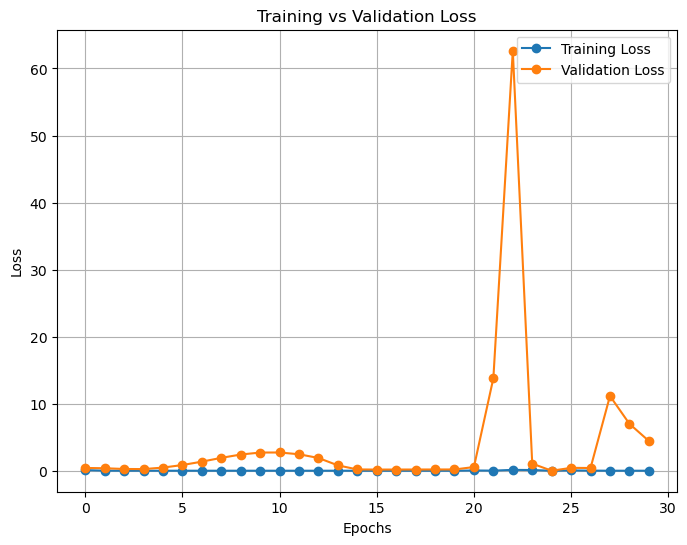

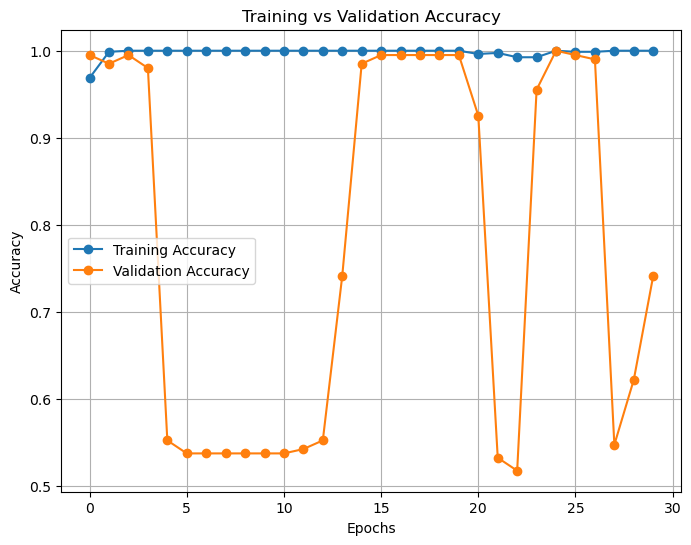

In [16]:
import matplotlib.pyplot as plt

# Ensure the history object has the required data
if 'loss' in history.history and 'val_loss' in history.history:
    # Plot training and validation loss
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.legend()
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

if 'accuracy' in history.history and 'val_accuracy' in history.history:
    # Plot training and validation accuracy
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.legend()
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.show()


In [ ]:
# code for face recognition 



In [18]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import pickle
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# Load the trained model
try:
    model = load_model("models/FacedataModel.h5")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

# Compile the model to avoid warnings
model.compile(optimizer=Adam(), loss=CategoricalCrossentropy(), metrics=['accuracy'])

# Load the label map
try:
    with open('models/label_map.pkl', 'rb') as f:
        label_map = pickle.load(f)
except FileNotFoundError:
    print("Error: label_map.pkl file not found!")
    exit()

# Reverse the label map for easy lookup
reverse_label_map = {v: k for k, v in label_map.items()}

# Set a stricter confidence threshold
UNKNOWN_THRESHOLD = 0.8

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
if face_cascade.empty():
    print("Error loading Haar Cascade!")
    exit()

# Open the webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

print("Starting real-time face recognition. Press 'q' to quit.")

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    if not ret:
        print("Failed to capture frame. Exiting...")
        break

    # Convert the frame to grayscale for face detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(64, 64))

    for (x, y, w, h) in faces:
        # Extract and preprocess the face region
        face_gray = gray[y:y + h, x:x + w]
        try:
            face_resized = cv2.resize(face_gray, (64, 64))  # Resize to 64x64
            face_normalized = face_resized.astype("float32") / 255.0  # Normalize to [0, 1]
            face_rgb = np.stack([face_normalized] * 3, axis=-1)  # Convert to 3-channel RGB
            face_reshaped = np.expand_dims(face_rgb, axis=0)  # Add batch dimension

            # Predict the class
            predictions = model.predict(face_reshaped, verbose=0)
            class_index = np.argmax(predictions)  # Index of the highest confidence
            confidence = np.max(predictions)  # Highest confidence level

            # Debugging information
            print(f"Predictions: {predictions}")
            print(f"Predicted class index: {class_index}, Confidence: {confidence:.2f}")

            # Determine the label
            if confidence < UNKNOWN_THRESHOLD:  # Stricter threshold for "Unknown"
                user_id = "Unknown"
            else:
                user_id = reverse_label_map.get(class_index, "Unknown")  # Default to "Unknown" if index not in map

            # Display the result on the frame
            label = f"{user_id} ({confidence:.2f})"
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Draw rectangle around the face
            cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)  # Display the label

        except Exception as e:
            print(f"Error processing face: {e}")

    # Show the resulting frame
    cv2.imshow("Face Recognition", frame)

    # Break the loop if 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close OpenCV windows
cap.release()
cv2.destroyAllWindows()
print("Real-time face recognition ended.")


Starting real-time face recognition. Press 'q' to quit.
Predictions: [[9.9999893e-01 1.0162909e-06]]
Predicted class index: 0, Confidence: 1.00
Predictions: [[1.0000000e+00 7.9543086e-18]]
Predicted class index: 0, Confidence: 1.00
Predictions: [[9.9999666e-01 3.3578251e-06]]
Predicted class index: 0, Confidence: 1.00
Predictions: [[9.999970e-01 3.010591e-06]]
Predicted class index: 0, Confidence: 1.00
Predictions: [[9.9999976e-01 2.8640770e-07]]
Predicted class index: 0, Confidence: 1.00
Predictions: [[1.0000000e+00 3.1098832e-10]]
Predicted class index: 0, Confidence: 1.00
Predictions: [[1.000000e+00 9.641634e-15]]
Predicted class index: 0, Confidence: 1.00
Predictions: [[5.7453025e-15 1.0000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[5.7453025e-15 1.0000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[2.8363276e-13 1.0000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[4.827061e-38 1.000000e+00]]
Predicted class index: 1,

Model file not found. Training a new model...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.7604 - loss: 0.4301 - val_accuracy: 0.9950 - val_loss: 0.0630
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.9950 - val_loss: 0.0885
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9950 - val_loss: 0.0977
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9990 - loss: 0.0034 - val_accuracy: 0.9950 - val_loss: 0.0692
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9983 - loss: 0.0123 - val_accuracy: 0.9950 - val_loss: 0.0580
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9950 - val_loss: 0.1037
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 1.0000 - loss: 1.8047e-04 - val_accuracy: 0.9950 - val_loss: 0.1086
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy

Model saved to FacedataModel.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9892 - loss: 0.1568
Test accuracy: 0.9950000047683716
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


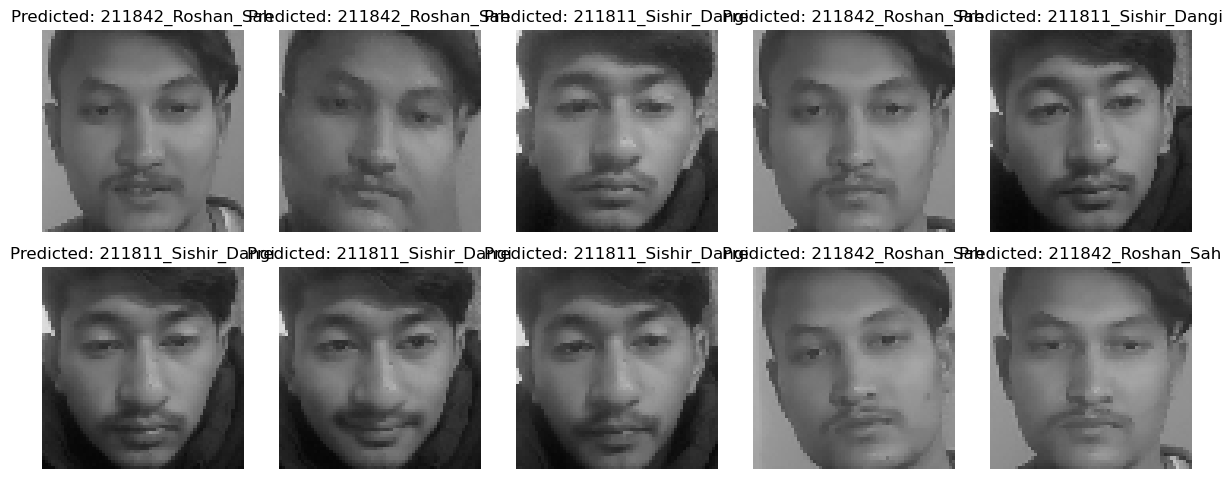

In [3]:
import os
import numpy as np
import cv2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load dataset
def load_data(dataset_path):
    images = []
    labels = []
    label_map = {}  # Map user ID to class index
    class_index = 0

    for user_id in os.listdir(dataset_path):
        user_folder = os.path.join(dataset_path, user_id)
        if os.path.isdir(user_folder):
            if user_id not in label_map:
                label_map[user_id] = class_index
                class_index += 1
            for image_name in os.listdir(user_folder):
                image_path = os.path.join(user_folder, image_name)
                image = cv2.imread(image_path)
                image = cv2.resize(image, (64, 64))  # Resize to 64x64
                images.append(image)
                labels.append(label_map[user_id])  # Use class index

    return np.array(images), np.array(labels), label_map

# Define the CNN model
def create_model(output_classes):
    model = Sequential([
        Input(shape=(64, 64, 3)),  # Input layer with the specified shape
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(output_classes, activation='softmax')  # Output layer with softmax for multiple classes
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Load the data
dataset_path = "dataset"  # Change to your actual dataset path
if not os.path.exists(dataset_path):
    print(f"Dataset directory '{dataset_path}' not found.")
    exit()

X, y, label_map = load_data(dataset_path)

# Normalize the images
X = X.astype('float32') / 255.0

# One-hot encode labels
y = to_categorical(y)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check if the model file exists
model_file = 'FacedataModel.h5'

if os.path.exists(model_file):
    print("Loading existing model...")
    model = load_model(model_file)
else:
    print("Model file not found. Training a new model...")
    model = create_model(y.shape[1])
    
    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
    
    # Save the trained model to a file
    model.save(model_file)
    print(f"Model saved to {model_file}")

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

# Make predictions on the test set
predictions = model.predict(X_test)

# Plot the test images with their predicted labels
num_images_to_display = 10
plt.figure(figsize=(12, 12))  # Adjust the size of the figure
for i in range(num_images_to_display):
    plt.subplot(5, 5, i + 1)  # Display images in a 5x5 grid
    plt.imshow(X_test[i])  # Directly display the image, no reshaping needed for RGB
    predicted_index = np.argmax(predictions[i])  # Get the predicted label index

    # Reverse label_map to map index to user ID
    reverse_label_map = {v: k for k, v in label_map.items()}
    predicted_label = reverse_label_map.get(predicted_index, "Unknown")  # Default to "Unknown" if not found

    plt.title(f"Predicted: {predicted_label}")
    plt.axis('off')  # Hide axis ticks

plt.tight_layout()  # Adjust subplots to fit into the figure area
plt.show()
